In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [9]:
severity_df = pd.read_csv("../datasets/severity_dataset.csv")

severity_df.head()

,Target,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Heart_Rate,Serum_Creatinine,Blood_Urea_Nitrogen,eGFR,...,Fasting_Glucose,HbA1c,Cholesterol,Triglycerides,Serum_Albumin,Total_Protein,Diabetes,Hypertension,Smoking_Status,Family_History_Kidney
0,Healthy Kidney,38,0,33,114,78,78,0,10,117,...,97,4.677411,211,203,4,5.156141,No,No,Yes,No
1,Severe CKD (Stage 4),76,0,28,166,103,92,5,84,25,...,111,9.490302,194,210,2,7.922118,No,No,No,No
2,Healthy Kidney,63,0,33,109,79,98,0,17,109,...,125,6.023745,243,138,4,6.606848,No,No,No,Yes
3,Healthy Kidney,54,0,31,107,62,109,0,10,107,...,127,5.772014,163,276,4,6.651897,No,Yes,No,Yes
4,Healthy Kidney,20,0,20,111,63,92,0,17,97,...,127,8.483288,221,264,4,6.400641,No,Yes,Yes,No


In [12]:
print("Shape of Dataset:", severity_df.shape)

print("\nColumns:")
print(severity_df.columns.tolist())

print("\nData Types:")
print(severity_df.dtypes)

print("\nMissing Values:")
print(severity_df.isnull().sum())

Shape of Dataset: (4800, 36)

Columns:
['Target', 'Age', 'Gender', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'Heart_Rate', 'Serum_Creatinine', 'Blood_Urea_Nitrogen', 'eGFR', 'Urine_Albumin', 'Urine_Protein', 'Albumin_Creatinine_Ratio', 'Urine_Specific_Gravity', 'Sodium', 'Potassium', 'Calcium', 'Phosphorus', 'Chloride', 'Bicarbonate', 'Hemoglobin', 'RBC_Count', 'WBC_Count', 'Platelet_Count', 'Packed_Cell_Volume', 'Blood_Glucose_Random', 'Fasting_Glucose', 'HbA1c', 'Cholesterol', 'Triglycerides', 'Serum_Albumin', 'Total_Protein', 'Diabetes', 'Hypertension', 'Smoking_Status', 'Family_History_Kidney']

Data Types:
Target                          str
Age                           int64
Gender                        int64
BMI                           int64
Systolic_BP                   int64
Diastolic_BP                  int64
Heart_Rate                    int64
Serum_Creatinine              int64
Blood_Urea_Nitrogen           int64
eGFR                          int64
Urine_Albumin            

In [13]:
# Check missing values in each column
missing_values = severity_df.isnull().sum()

print("Missing Values in Each Column:\n")
print(missing_values)

print("\nTotal Missing Values :", missing_values.sum())

Missing Values in Each Column:

Target                      0
Age                         0
Gender                      0
BMI                         0
Systolic_BP                 0
Diastolic_BP                0
Heart_Rate                  0
Serum_Creatinine            0
Blood_Urea_Nitrogen         0
eGFR                        0
Urine_Albumin               0
Urine_Protein               0
Albumin_Creatinine_Ratio    0
Urine_Specific_Gravity      0
Sodium                      0
Potassium                   0
Calcium                     0
Phosphorus                  0
Chloride                    0
Bicarbonate                 0
Hemoglobin                  0
RBC_Count                   0
WBC_Count                   0
Platelet_Count              0
Packed_Cell_Volume          0
Blood_Glucose_Random        0
Fasting_Glucose             0
HbA1c                       0
Cholesterol                 0
Triglycerides               0
Serum_Albumin               0
Total_Protein               0
Diabetes

In [15]:
# Separate numerical and categorical columns

numerical_cols = severity_df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = severity_df.select_dtypes(include=['object','string']).columns

# Numerical Missing Values
num_imputer = SimpleImputer(strategy='mean')
severity_df[numerical_cols] = num_imputer.fit_transform(severity_df[numerical_cols])

# Categorical Missing Values
cat_imputer = SimpleImputer(strategy='most_frequent')
severity_df[categorical_cols] = cat_imputer.fit_transform(severity_df[categorical_cols])

print("Missing values handled successfully.")

Missing values handled successfully.


In [16]:
from sklearn.preprocessing import LabelEncoder

# Create a dictionary to store encoders
label_encoders = {}

# Find categorical columns
categorical_cols = severity_df.select_dtypes(include=['object', 'string']).columns

# Apply Label Encoding
for col in categorical_cols:
    le = LabelEncoder()
    severity_df[col] = le.fit_transform(severity_df[col].astype(str))
    label_encoders[col] = le

print("Label Encoding completed successfully.")

# Display the first 5 rows
severity_df.head()

Label Encoding completed successfully.


,Target,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Heart_Rate,Serum_Creatinine,Blood_Urea_Nitrogen,eGFR,...,Fasting_Glucose,HbA1c,Cholesterol,Triglycerides,Serum_Albumin,Total_Protein,Diabetes,Hypertension,Smoking_Status,Family_History_Kidney
0,0,38.0,0.0,33.0,114.0,78.0,78.0,0.0,10.0,117.0,...,97.0,4.677411,211.0,203.0,4.0,5.156141,0,0,1,0
1,4,76.0,0.0,28.0,166.0,103.0,92.0,5.0,84.0,25.0,...,111.0,9.490302,194.0,210.0,2.0,7.922118,0,0,0,0
2,0,63.0,0.0,33.0,109.0,79.0,98.0,0.0,17.0,109.0,...,125.0,6.023745,243.0,138.0,4.0,6.606848,0,0,0,1
3,0,54.0,0.0,31.0,107.0,62.0,109.0,0.0,10.0,107.0,...,127.0,5.772014,163.0,276.0,4.0,6.651897,0,1,0,1
4,0,20.0,0.0,20.0,111.0,63.0,92.0,0.0,17.0,97.0,...,127.0,8.483288,221.0,264.0,4.0,6.400641,0,1,1,0


In [17]:
print("Data Types After Label Encoding:\n")
print(severity_df.dtypes)

Data Types After Label Encoding:

Target                        int64
Age                         float64
Gender                      float64
BMI                         float64
Systolic_BP                 float64
Diastolic_BP                float64
Heart_Rate                  float64
Serum_Creatinine            float64
Blood_Urea_Nitrogen         float64
eGFR                        float64
Urine_Albumin               float64
Urine_Protein               float64
Albumin_Creatinine_Ratio    float64
Urine_Specific_Gravity      float64
Sodium                      float64
Potassium                   float64
Calcium                     float64
Phosphorus                  float64
Chloride                    float64
Bicarbonate                 float64
Hemoglobin                  float64
RBC_Count                   float64
WBC_Count                   float64
Platelet_Count              float64
Packed_Cell_Volume          float64
Blood_Glucose_Random        float64
Fasting_Glucose             fl

In [20]:
# Separate features and target

X = severity_df.drop("Target", axis=1)
y = severity_df["Target"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (4800, 35)
Target Shape: (4800,)


In [21]:
from sklearn.model_selection import train_test_split

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Features: (3840, 35)
Testing Features: (960, 35)
Training Labels: (3840,)
Testing Labels: (960,)


In [22]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")
print("Scaled Training Shape:", X_train_scaled.shape)
print("Scaled Testing Shape:", X_test_scaled.shape)

Feature scaling completed successfully.
Scaled Training Shape: (3840, 35)
Scaled Testing Shape: (960, 35)


In [23]:
from sklearn.linear_model import LogisticRegression

# Create the model
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
lr_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [24]:
# Predict on test data
y_pred_lr = lr_model.predict(X_test_scaled)

print("Predictions completed.")

Predictions completed.


In [25]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy
accuracy = accuracy_score(y_test, y_pred_lr)
print("Accuracy:", round(accuracy * 100, 2), "%")

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_lr))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Accuracy: 100.0 %

Confusion Matrix:

[[723   0   0   0   0]
 [  0  19   0   0   0]
 [  0   0 115   0   0]
 [  0   0   0  64   0]
 [  0   0   0   0  39]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       723
           1       1.00      1.00      1.00        19
           2       1.00      1.00      1.00       115
           3       1.00      1.00      1.00        64
           4       1.00      1.00      1.00        39

    accuracy                           1.00       960
   macro avg       1.00      1.00      1.00       960
weighted avg       1.00      1.00      1.00       960



In [26]:
from sklearn.tree import DecisionTreeClassifier

# Create the model
dt_model = DecisionTreeClassifier(
    random_state=42
)

# Train the model
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [27]:
# Make predictions
y_pred_dt = dt_model.predict(X_test)

print("Predictions completed.")

Predictions completed.


In [29]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", round(dt_accuracy * 100, 2), "%")

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_dt))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 100.0 %

Confusion Matrix:

[[723   0   0   0   0]
 [  0  19   0   0   0]
 [  0   0 115   0   0]
 [  0   0   0  64   0]
 [  0   0   0   0  39]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       723
           1       1.00      1.00      1.00        19
           2       1.00      1.00      1.00       115
           3       1.00      1.00      1.00        64
           4       1.00      1.00      1.00        39

    accuracy                           1.00       960
   macro avg       1.00      1.00      1.00       960
weighted avg       1.00      1.00      1.00       960



In [30]:
from sklearn.ensemble import RandomForestClassifier

# Create the model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [31]:
# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 100.0 %

Confusion Matrix:

[[723   0   0   0   0]
 [  0  19   0   0   0]
 [  0   0 115   0   0]
 [  0   0   0  64   0]
 [  0   0   0   0  39]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       723
           1       1.00      1.00      1.00        19
           2       1.00      1.00      1.00       115
           3       1.00      1.00      1.00        64
           4       1.00      1.00      1.00        39

    accuracy                           1.00       960
   macro avg       1.00      1.00      1.00       960
weighted avg       1.00      1.00      1.00       960



In [32]:
import pandas as pd

# Create a comparison table
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy (%)": [
        accuracy * 100,
        dt_accuracy * 100,
        rf_accuracy * 100
    ]
})

# Sort by accuracy
model_results = model_results.sort_values(by="Accuracy (%)", ascending=False)

print(model_results)

                 Model  Accuracy (%)
0  Logistic Regression         100.0
1        Decision Tree         100.0
2        Random Forest         100.0


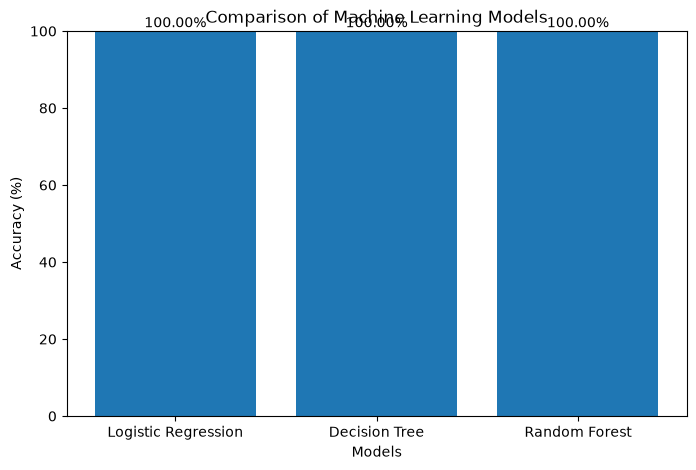

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(model_results["Model"], model_results["Accuracy (%)"])

plt.title("Comparison of Machine Learning Models")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")

plt.ylim(0, 100)

for i, value in enumerate(model_results["Accuracy (%)"]):
    plt.text(i, value + 1, f"{value:.2f}%", ha='center')

plt.show()

In [34]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    estimator=rf_model,
    X=X,
    y=y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nAverage Accuracy: {:.4f}".format(cv_scores.mean()))
print("Standard Deviation: {:.4f}".format(cv_scores.std()))

Cross Validation Scores:
[1. 1. 1. 1. 1.]

Average Accuracy: 1.0000
Standard Deviation: 0.0000


In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display top 10 features
print(feature_importance.head(10))

                     Feature  Importance
8                       eGFR    0.143431
7        Blood_Urea_Nitrogen    0.111787
6           Serum_Creatinine    0.102010
4               Diastolic_BP    0.095293
9              Urine_Albumin    0.092752
3                Systolic_BP    0.092037
29             Serum_Albumin    0.091465
11  Albumin_Creatinine_Ratio    0.079375
10             Urine_Protein    0.061087
19                Hemoglobin    0.037341


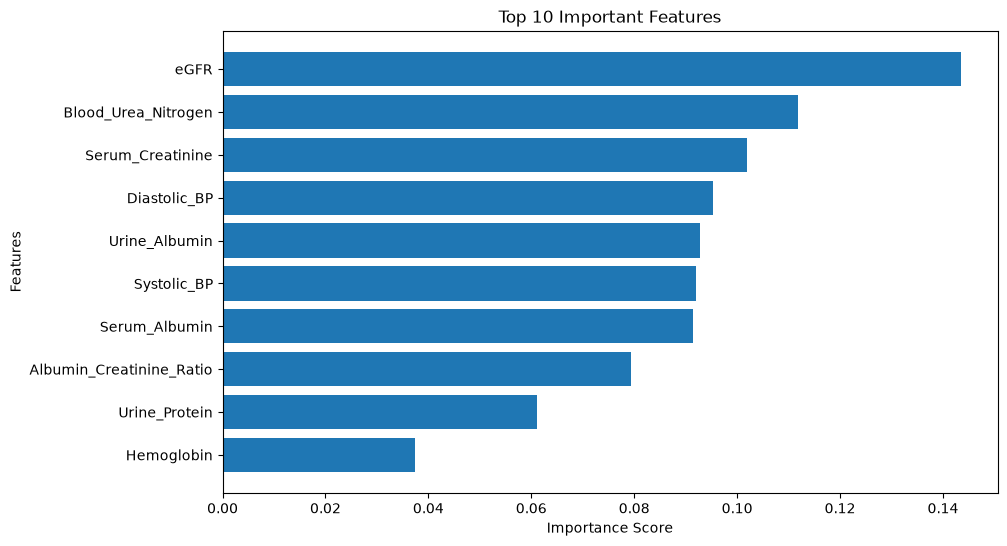

In [37]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

In [38]:
# Predict the first patient from the test set
sample = X_test.iloc[[0]]

prediction = rf_model.predict(sample)

print("Predicted CKD Severity:", prediction[0])

Predicted CKD Severity: 0


In [39]:
# If Target was label encoded
print("Predicted Class:", label_encoders["Target"].inverse_transform(prediction))

Predicted Class: ['Healthy Kidney']


In [40]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_rf
})

print(comparison.head(20))

    Actual  Predicted
0        0          0
1        4          4
2        0          0
3        0          0
4        0          0
5        0          0
6        0          0
7        0          0
8        0          0
9        0          0
10       0          0
11       4          4
12       0          0
13       0          0
14       4          4
15       0          0
16       0          0
17       0          0
18       0          0
19       4          4


In [41]:
print(severity_df["Target"].unique())

[0 4 2 3 1]


In [42]:
# Select one patient from the test set
sample = X_test.iloc[[0]]

# Predict the stage
prediction = rf_model.predict(sample)

print("Predicted Target:", prediction[0])
print("Actual Target:", y_test.iloc[0])

Predicted Target: 0
Actual Target: 0


In [43]:
stage_mapping = {
    0: "Stage 1",
    1: "Stage 2",
    2: "Stage 3",
    3: "Stage 4",
    4: "Stage 5"
}

predicted_stage = stage_mapping[prediction[0]]
actual_stage = stage_mapping[y_test.iloc[0]]

print("Predicted CKD Stage:", predicted_stage)
print("Actual CKD Stage:", actual_stage)

Predicted CKD Stage: Stage 1
Actual CKD Stage: Stage 1


In [44]:
predictions = rf_model.predict(X_test)

results = pd.DataFrame({
    "Actual Stage": y_test.values,
    "Predicted Stage": predictions
})

print(results.head(20))

    Actual Stage  Predicted Stage
0              0                0
1              4                4
2              0                0
3              0                0
4              0                0
5              0                0
6              0                0
7              0                0
8              0                0
9              0                0
10             0                0
11             4                4
12             0                0
13             0                0
14             4                4
15             0                0
16             0                0
17             0                0
18             0                0
19             4                4


In [45]:
results["Actual Stage"] = results["Actual Stage"].map(stage_mapping)
results["Predicted Stage"] = results["Predicted Stage"].map(stage_mapping)

print(results.head(20))

   Actual Stage Predicted Stage
0       Stage 1         Stage 1
1       Stage 5         Stage 5
2       Stage 1         Stage 1
3       Stage 1         Stage 1
4       Stage 1         Stage 1
5       Stage 1         Stage 1
6       Stage 1         Stage 1
7       Stage 1         Stage 1
8       Stage 1         Stage 1
9       Stage 1         Stage 1
10      Stage 1         Stage 1
11      Stage 5         Stage 5
12      Stage 1         Stage 1
13      Stage 1         Stage 1
14      Stage 5         Stage 5
15      Stage 1         Stage 1
16      Stage 1         Stage 1
17      Stage 1         Stage 1
18      Stage 1         Stage 1
19      Stage 5         Stage 5
